# Trabajo Práctico N°3 — Tercera Pre-Entrega
## Transformación Avanzada, Reducción Espacial y Algoritmos Descriptivos Complejos

---
# 1. Setup e importación de datos

In [1]:
# instalación de librerías necesarias
#!pip install scikit-learn prince geopandas scipy matplotlib seaborn geopy

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import requests
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Prince (MCA)
import prince

# Scipy
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, spearmanr
from scipy.spatial.distance import cdist

# Configuración general
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_columns', None)
SEED = 42

### 1.1 Carga del dataset limpio

Cargamos el dataframe_limpio.tsv generado al final de la entrega anterior (TP2). Este archivo ya pasó por todo el pipeline de limpieza, feature engineering, imputación y tratamiento de outliers.

In [3]:
df = pd.read_csv('../data/raw/dataframe_limpio.tsv', sep='\t')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 51,996 filas × 48 columnas


,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_oficial,moneda,accesible_movilidad_reducida,acepta_caucion,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,dependencia_servicio,dormitorios,expensas_incluidas_en_precio,gimnasio,lavadero,m2_total,ofrece_financiacion,parrilla,pileta,portero,sum,terraza,tiene_expensas,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count,m2_relativo_barrio
0,58757240,zonaprop,alquiler,"750,000.000",Mansilla,"2,936.000",0,0,0,0,0,1,0,Recoleta,ars,0,0,0,2.000,36.000,0,0,1,0,1.000,0,1.000,False,0,1,60.000,0,0,0,0,0,1,1.000,"300,000.000",0,"12,500.000",estandar,estandar,13.528,4.111,9.434,5.000,NaN
1,58818211,zonaprop,alquiler,"1,700,000.000",Cespedes,"2,300.000",0,0,0,1,0,0,0,Belgrano,ars,0,1,0,3.000,35.000,0,0,1,0,2.000,0,2.000,False,0,1,114.000,0,1,0,0,0,1,1.000,"400,000.000",0,"14,912.281",estandar,estandar,14.346,4.745,9.610,7.000,NaN
2,58564550,zonaprop,alquiler,"2,500.000",Riobamba,"1,200.000",0,0,0,1,1,1,0,Recoleta,usd,0,0,0,4.000,48.500,0,0,1,0,2.000,0,2.000,False,1,1,121.000,0,1,1,0,0,0,1.000,"1,150,000.000",0,20.661,estandar,estandar,7.824,4.804,3.076,9.000,NaN
3,58314210,zonaprop,alquiler,"1,300.000",Pereyra Lucena,"2,500.000",0,0,0,1,0,1,1,Palermo,usd,0,0,0,2.000,20.000,1,0,1,0,1.000,0,1.000,False,0,0,66.000,0,0,0,0,0,1,1.000,"384,500.000",0,19.697,estandar,estandar,7.171,4.205,3.030,7.000,NaN
4,58810878,zonaprop,alquiler,"3,800.000",Lola Mora,400.000,0,0,0,1,1,0,0,Puerto Madero,usd,0,0,0,3.000,14.000,0,0,0,0,2.000,0,2.000,False,1,0,117.000,0,0,1,0,0,0,1.000,"507,000.000",0,32.479,premium,premium,8.243,4.771,3.511,5.000,NaN


In [4]:
# Revisión rápida de columnas disponibles
print('Columnas disponibles:')
print(df.columns.tolist())
print('\nDistribución por operación:')
print(df['operacion'].value_counts())

Columnas disponibles:
['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura', 'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda', 'accesible_movilidad_reducida', 'acepta_caucion', 'agua_caliente_central', 'ambientes', 'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños', 'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'expensas', 'sobre_avenida', 'precio_por_m2', 'segmento_zona', 'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2', 'amenities_count', 'm2_relativo_barrio']

Distribución por operación:
operacion
venta                28643
alquiler             18220
alquiler_temporal     5133
Name: count, dtype: int64


Asimismo, importamos los KPIs previamente calculados

In [5]:
df_kpis = pd.read_csv('../data/raw/dataframe_kpis.tsv', sep='\t')
print(f'Dataset cargado: {df_kpis.shape[0]:,} filas × {df_kpis.shape[1]} columnas')
df_kpis.head()

Dataset cargado: 48 filas × 18 columnas


,barrio_oficial,rent_bruta_lp_pct,años_recupero,precio_m2_mediano,precio_m2_promedio,retorno_neto_lp_mediano,rent_neta_lp_pct,m2_relativo_barrio_mediano,rent_bruta_temp_pct,indice_bruto,modalidad_optima_bruta,ingreso_anual_mediano,costo_propietario_mediano,retorno_neto_temp_mediano,costo_expensas_pct,rent_neta_temp_pct,indice_neto,modalidad_optima_neta
0,Agronomia,5.140,19.500,"2,375.000","2,452.000","5,088.339",5,1.000,5.310,1.030,Temporario,"5,256.000","1,187.279","4,068.721",1.000,4.000,0.800,Largo plazo
1,Almagro,4.550,22.000,"2,297.000","2,352.000","5,681.979",5,1.000,4.560,1.000,Temporario,"5,694.000","1,187.279","4,407.943",1.000,4.000,0.800,Largo plazo
2,Balvanera,6.120,16.300,"1,645.000","1,731.000","5,512.367",6,1.000,5.570,0.910,Largo plazo,"5,014.558","1,297.527","3,559.887",1.000,4.000,0.670,Largo plazo
3,Barracas,5.300,18.900,"2,091.000","2,160.000","6,614.841",5,1.000,4.960,0.940,Largo plazo,"6,190.813","1,653.710","4,690.304",1.000,4.000,0.800,Largo plazo
4,Belgrano,4.240,23.600,"3,112.000","3,351.000","9,328.622",4,1.000,3.240,0.760,Largo plazo,"7,119.435","1,526.502","5,502.700",1.000,3.000,0.750,Largo plazo


In [6]:
df_kpis.columns

Index(['barrio_oficial', 'rent_bruta_lp_pct', 'años_recupero',
       'precio_m2_mediano', 'precio_m2_promedio', 'retorno_neto_lp_mediano',
       'rent_neta_lp_pct', 'm2_relativo_barrio_mediano', 'rent_bruta_temp_pct',
       'indice_bruto', 'modalidad_optima_bruta', 'ingreso_anual_mediano',
       'costo_propietario_mediano', 'retorno_neto_temp_mediano',
       'costo_expensas_pct', 'rent_neta_temp_pct', 'indice_neto',
       'modalidad_optima_neta'],
      dtype='object')

### 1.2 Preparación para análisis

Aunque fue útil en nuestro análisis inicial, ara poder llegar a conclusiones más robustas, decidimos descartar las pocas instancias en las cuales las ventas de propiedades están en ARS. Aún al pasarlos a USD, estos representarían valores muy bajos debido a las condiciones que mencionamos previamente (propiedades en mal estado). 

In [7]:
df = df[~((df['operacion'] == 'venta') & (df['moneda'] == 'ars'))]

In [8]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count        mean      median         std  \
moneda operacion                                                      
ars    alquiler           12339 803,925.003 700,000.000 359,879.307   
       alquiler_temporal    459 784,724.887 750,000.000 253,418.624   
usd    alquiler            5881   1,713.305   1,200.000   1,431.851   
       alquiler_temporal   4674   1,052.809     800.000     667.782   
       venta              28639 237,102.007 145,000.000 346,399.372   

                                 min           max  
moneda operacion                                    
ars    alquiler          115,000.000 4,500,000.000  
       alquiler_temporal 120,000.000 2,000,000.000  
usd    alquiler              300.000    10,000.000  
       alquiler_temporal     250.000     5,000.000  
       venta              24,000.000 9,500,000.000

Asimismo, para poder comparar los precios de los distintos alquileres entre sí, creamos una columna con todos los precios en USD.

In [9]:
from datetime import date
import requests

def obtener_dolar_oficial():
    hoy = date.today().strftime("%Y-%m-%d")

    try:
        url = f"https://estadisticascambiarias.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD?fecha={hoy}"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['results']['detalle'][0]['tipoCotizacion']
        print(f"✓ [BCRA oficial] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ BCRA oficial falló: {e}")

    try:
        url = "https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=1&sort=desc"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['data'][0][1]
        print(f"✓ [datos.gob.ar] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ datos.gob.ar falló: {e}")

    try:
        url = "https://dolarapi.com/v1/dolares/oficial"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['venta']
        print(f"✓ [dolarapi.com] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ dolarapi.com falló: {e}")

    print("\n⚠ No se pudo obtener el tipo de cambio de ninguna fuente.")
    print("  Ingresalo manualmente en la siguiente línea:")
    return None

TIPO_DE_CAMBIO_USD = obtener_dolar_oficial()

df['precio_usd'] = df.apply(lambda row: row['precio'] / TIPO_DE_CAMBIO_USD if row['moneda'] == 'ars' else row['precio'], axis=1)
df['precio_por_m2_usd'] = df.apply(lambda row: row['precio_por_m2'] / TIPO_DE_CAMBIO_USD if row['moneda'] == 'ars' else row['precio_por_m2'], axis=1)
print("✓ Precios convertidos a USD usando tipo de cambio oficial.")

✗ BCRA oficial falló: HTTPSConnectionPool(host='estadisticascambiarias.bcra.gob.ar', port=443): Max retries exceeded with url: /estadisticascambiarias/v1.0/Cotizaciones/USD?fecha=2026-05-23 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000239F9493890>: Failed to resolve 'estadisticascambiarias.bcra.gob.ar' ([Errno 11001] getaddrinfo failed)"))
✓ [datos.gob.ar] Dólar oficial al 2026-05-23: $ 1,415.00 ARS/USD
✓ Precios convertidos a USD usando tipo de cambio oficial.


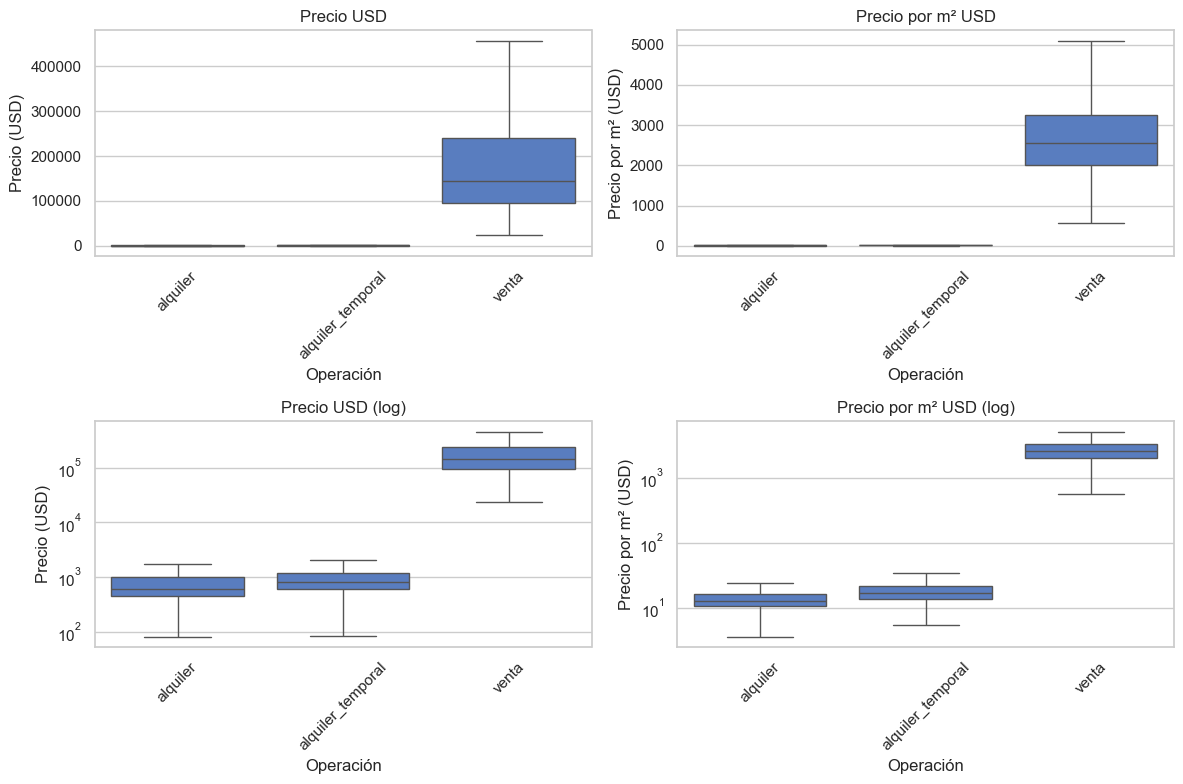

In [11]:
df_box_precio = df.dropna(subset=["operacion", "precio_usd"]).copy()
df_box_m2 = df.dropna(subset=["operacion", "precio_por_m2_usd"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Precio USD
sns.boxplot(data=df_box_precio, x="operacion", y="precio_usd", showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title("Precio USD")
axes[0, 0].set_xlabel("Operación")
axes[0, 0].set_ylabel("Precio (USD)")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Precio por m2 USD
sns.boxplot(data=df_box_m2, x="operacion", y="precio_por_m2_usd", showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Precio por m² USD")
axes[0, 1].set_xlabel("Operación")
axes[0, 1].set_ylabel("Precio por m² (USD)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Precio USD en log
sns.boxplot(data=df_box_precio, x="operacion", y="precio_usd", showfliers=False, ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Precio USD (log)")
axes[1, 0].set_xlabel("Operación")
axes[1, 0].set_ylabel("Precio (USD)")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Precio por m2 USD en log
sns.boxplot(data=df_box_m2, x="operacion", y="precio_por_m2_usd", showfliers=False, ax=axes[1, 1])
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Precio por m² USD (log)")
axes[1, 1].set_xlabel("Operación")
axes[1, 1].set_ylabel("Precio por m² (USD)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
# 2. Enriquecimiento Espacial

En esta sección cruzamos nuestra matriz inmobiliaria con dos fuentes exógenas:

1. **Estaciones de Subte (GCBA):** calculamos la distancia euclidiana de cada propiedad a la estación de subte más cercana.
2. **GeoJSON de Barrios (GCBA):** incorporamos el polígono geográfico de cada barrio para enriquecer el análisis espacial.

El objetivo es testear la **Hipótesis 4** (la cercanía al subte impacta en el precio/m²) y construir la variable dist_subte_km que luego usaremos en el clustering y en los modelos explicativos.

### 2.1 Descarga de fuentes exógenas

Comenzamos obteniendo las latitudes y longitudes de las estaciones de subte para analizar la cercanía de las propiedades a las mismas. 

In [27]:
URL_SUBTE = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/'
    'subte-estaciones/estaciones-de-subte.csv'
)

subte = pd.read_csv(URL_SUBTE, sep=';')
print('Columnas del CSV de subte:', subte.columns.tolist())
subte.head(3)

Columnas del CSV de subte: ['long', 'lat', 'id', 'estacion', 'linea']


,long,lat,id,estacion,linea
0,"-58,39892759","-34,63575018",1,CASEROS,H
1,"-58,40096956","-34,62937566",2,INCLAN - MEZQUITA AL AHMAD,H
2,"-58,40232273","-34,62309232",3,HUMBERTO 1Â°,H


In [14]:
subte.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   long      90 non-null     object
 1   lat       90 non-null     object
 2   id        90 non-null     int64 
 3   estacion  90 non-null     object
 4   linea     90 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.6+ KB


In [15]:
col_map = {}
for col in subte.columns:
    cl = col.lower()
    if 'lat' in cl:
        col_map[col] = 'lat_subte'
    elif 'long' in cl:
        col_map[col] = 'lon_subte'
    elif 'nombre' in cl or 'estacion' in cl or 'station' in cl:
        col_map[col] = 'nombre_estacion'
    elif 'linea' in cl or 'line' in cl:
        col_map[col] = 'linea'

subte = subte.rename(columns=col_map)
subte = subte[['lon_subte', 'lat_subte']].dropna()
subte['lat_subte'] = subte['lat_subte'].str.replace(',', '', regex=False)
subte['lon_subte'] = subte['lon_subte'].str.replace(',', '', regex=False)
subte['lat_subte'] = pd.to_numeric(subte['lat_subte'])
subte['lon_subte'] = pd.to_numeric(subte['lon_subte'])
subte = subte.dropna()
print(f'Estaciones de subte disponibles: {len(subte)}')
subte.head()

Estaciones de subte disponibles: 90


,lon_subte,lat_subte
0,-5839892759,-3463575018
1,-5840096956,-3462937566
2,-5840232273,-3462309232
3,-5840473172,-3461524215
4,-5840603638,-3460893524


### 2.2 Geocodificación de propiedades 

No todas las propiedades tienen coordenadas exactas en el dataset. Como el GeoJSON de barrios contiene los centroides de cada polígono, usamos el **centroide del barrio** como proxy de ubicación para calcular la distancia al subte más cercano.

Esta aproximación es coherente con el nivel de análisis: queremos capturar diferencias *entre barrios*, no *dentro del barrio*. Para un análisis a mayor granularidad (por cuadra), sería necesario geocodificar cada dirección.

In [ ]:
#TODO verificar esto. no me parece la mejor forma, pero averigue formas de obtener la latitud y longitud a base de las direcciones,
#como google maps y geoapify, pero estoy bastante segura de que para la cantidad de filas que tenemos hay que pagar

In [17]:
# ── GeoJSON de Barrios de CABA ──
URL_GEOJSON = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/'
    'ministerio-de-educacion/barrios/barrios.geojson'
)
gdf_barrios = gpd.read_file(URL_GEOJSON)

# Normalizamos el nombre de la columna de barrio
for col in gdf_barrios.columns:
    if 'nombre' in col.lower():
        gdf_barrios = gdf_barrios.rename(columns={col: 'barrio_oficial'})
        break

# Calculamos el centroide de cada polígono
gdf_barrios = gdf_barrios.set_crs('EPSG:4326', allow_override=True)
gdf_barrios['centroid'] = gdf_barrios.geometry.centroid
gdf_barrios['lat_barrio'] = gdf_barrios['centroid'].y
gdf_barrios['lon_barrio'] = gdf_barrios['centroid'].x

centroides = gdf_barrios[['barrio_oficial', 'lat_barrio', 'lon_barrio']].copy()
print(f'Barrios con centroide calculado: {len(centroides)}')
centroides.head()

Barrios con centroide calculado: 48


,barrio_oficial,lat_barrio,lon_barrio
0,Agronomia,-34.593,-58.489
1,Almagro,-34.609,-58.422
2,Balvanera,-34.609,-58.403
3,Barracas,-34.646,-58.384
4,Belgrano,-34.555,-58.450


### 2.3 Cálculo de distancia al subte más cercano

Usamos la **distancia euclidiana en grados** como aproximación. Para CABA (latitud ~34°S), 1 grado de latitud ≈ 111 km y 1 grado de longitud ≈ 91 km. Convertimos a kilómetros usando un factor de corrección simple.

In [18]:
def distancia_min_subte_km(lat, lon, subte_coords):
    """
    Calcula la distancia en km al subte más cercano usando una aproximación
    euclidiana corregida por latitud (válida para distancias cortas en CABA).

    Parámetros
    ----------
    lat, lon       : coordenadas del punto de consulta
    subte_coords   : array (N, 2) con [lat, lon] de cada estación

    Retorna
    -------
    float : distancia mínima en kilómetros
    """
    LAT_KM = 111.0          # km por grado de latitud
    LON_KM = 111.0 * np.cos(np.radians(lat))   # corregido por latitud

    dlat = (subte_coords[:, 0] - lat) * LAT_KM
    dlon = (subte_coords[:, 1] - lon) * LON_KM
    distancias = np.sqrt(dlat**2 + dlon**2)
    return distancias.min()


# Convertimos coordenadas de subte a array NumPy para eficiencia
subte_coords = subte[['lat_subte', 'lon_subte']].values

# Calculamos la distancia para cada barrio (centroide)
centroides['dist_subte_km'] = centroides.apply(
    lambda row: distancia_min_subte_km(row['lat_barrio'], row['lon_barrio'], subte_coords),
    axis=1
)

print('Distancia (km) al subte más cercano por barrio:')
print(centroides[['barrio_oficial', 'dist_subte_km']]
      .sort_values('dist_subte_km')
      .to_string(index=False))

Distancia (km) al subte más cercano por barrio:
   barrio_oficial       dist_subte_km
  Villa Riachuelo 387,375,943,302.248
     Villa Lugano 387,377,439,993.945
    Villa Soldati 387,378,289,380.796
        Mataderos 387,378,914,617.700
    Nueva Pompeya 387,379,611,530.129
Parque Avellaneda 387,379,777,969.214
         Barracas 387,379,976,456.172
          Liniers 387,380,207,771.031
 Parque Patricios 387,380,761,789.909
           Flores 387,380,828,048.303
       Villa Luro 387,380,862,605.971
 Parque Chacabuco 387,380,904,614.636
  Velez Sarsfield 387,381,310,657.011
          La Boca 387,381,336,650.566
        Versalles 387,381,420,476.271
            Boedo 387,381,434,980.479
         Floresta 387,381,636,630.164
     Constitucion 387,381,870,938.156
    San Cristobal 387,381,975,535.949
        San Telmo 387,382,183,409.354
       Villa Real 387,382,363,105.674
     Monte Castro 387,382,380,443.433
        Caballito 387,382,599,695.537
 Villa Santa Rita 387,382,655,713.086
  

In [19]:
# Fusionamos con el dataset principal
df = df.merge(centroides[['barrio_oficial', 'dist_subte_km', 'lat_barrio', 'lon_barrio']],
              on='barrio_oficial', how='left')

cobertura = df['dist_subte_km'].notna().mean() * 100
print(f'Cobertura del enriquecimiento espacial: {cobertura:.1f}% de los registros')
print(f'\nEstadísticas de dist_subte_km:')
print(df['dist_subte_km'].describe())

Cobertura del enriquecimiento espacial: 99.6% de los registros

Estadísticas de dist_subte_km:
count            51,773.000
mean    387,384,737,584.509
std           2,407,061.633
min     387,375,943,302.248
25%     387,383,202,314.935
50%     387,385,352,058.807
75%     387,386,409,004.544
max     387,389,117,450.542
Name: dist_subte_km, dtype: float64


### 2.4 Visualización espacial: precio/m² y distancia al subte

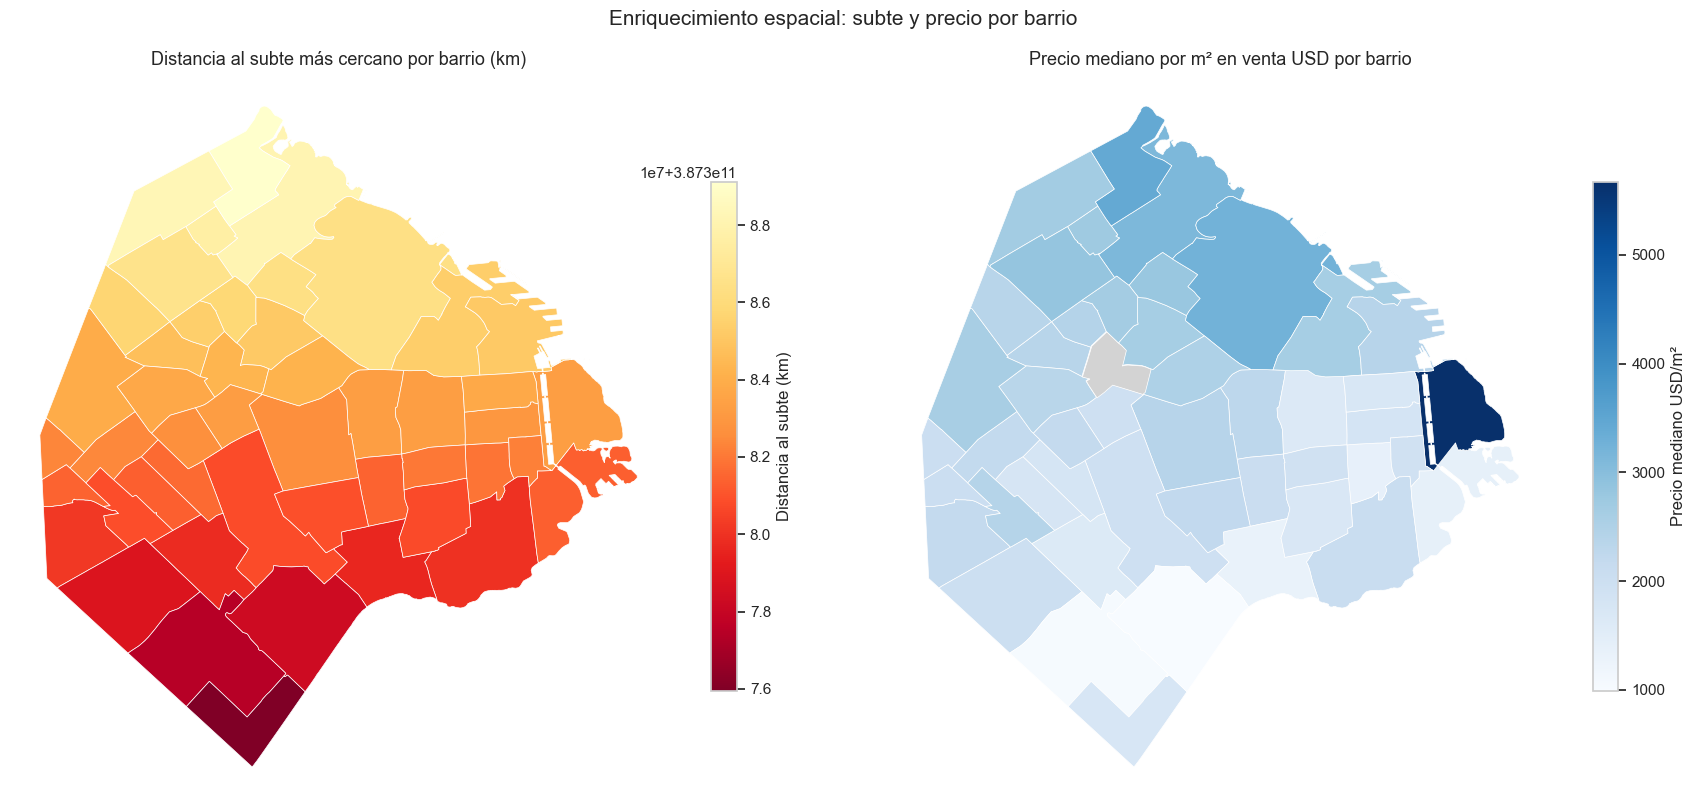

In [ ]:
# Mapa coroplético: distancia promedio al subte por barrio
dist_barrio = centroides.set_index('barrio_oficial')['dist_subte_km']
gdf_mapa = gdf_barrios.copy()
gdf_mapa['dist_subte_km'] = gdf_mapa['barrio_oficial'].map(dist_barrio)

# Precio mediano por m² en venta USD por barrio
precio_barrio = (
    df[(df['operacion'] == 'venta') & (df['moneda'] == 'usd')]
    .groupby('barrio_oficial')['precio_por_m2']
    .median()
)
gdf_mapa['precio_m2_mediano'] = gdf_mapa['barrio_oficial'].map(precio_barrio)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

gdf_mapa.plot(
    column='dist_subte_km', cmap='YlOrRd_r', linewidth=0.5,
    edgecolor='white', legend=True, ax=axes[0],
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Distancia al subte (km)', 'shrink': 0.7}
)
axes[0].set_title('Distancia al subte más cercano por barrio (km)', fontsize=13)
axes[0].axis('off')

gdf_mapa.plot(
    column='precio_m2_mediano', cmap='Blues', linewidth=0.5,
    edgecolor='white', legend=True, ax=axes[1],
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Precio mediano USD/m²', 'shrink': 0.7}
)
axes[1].set_title('Precio mediano por m² en venta USD por barrio', fontsize=13)
axes[1].axis('off')

plt.suptitle('Enriquecimiento espacial: subte y precio por barrio', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
# 3. Validación de Hipótesis

Formalizamos las hipótesis planteadas en la primera entrega utilizando herramientas estadísticas robustas. El umbral de significancia es **α = 0.05** en todos los tests.

| # | Hipótesis |
|---|---|
| H1 | En barrios turísticos, la rentabilidad neta temporaria > LP (diferencia significativa) |
| H2 | Los barrios con mayor precio/m² no son los de mayor rentabilidad neta |
| H3 | Los amenities incrementan el precio de venta pero no el de alquiler |
| H4 | La cercanía al subte genera un aumento significativo en el valor del m² |

### H1 — Rentabilidad Temporaria vs LP en barrios turísticos

Usamos **Mann-Whitney U** (no paramétrico) porque la distribución de rentabilidades no es normal. Para analizar esta hipótesis, selccionamos los barrios más mencionados en artículos turísticos. 
https://argentina.viajando.travel/tips/buenos-aires-el-destino-mas-elegido-los-turistas-extranjeros-2025-sus-atractivos-mas-visitados-n87653

In [ ]:
BARRIOS_TURISTICOS = ['Palermo', 'San Telmo', 'Recoleta', 'La Boca']

kpis = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis.copy()

kpis['es_turistico'] = kpis.index.isin(BARRIOS_TURISTICOS)

turisticos    = kpis[kpis['es_turistico']]
no_turisticos = kpis[~kpis['es_turistico']]

print('=== H1: Rentabilidad Neta Temporaria > LP en barrios turísticos ===')
print('H₀: rent_neta_temp ≤ rent_neta_lp  |  H₁: rent_neta_temp > rent_neta_lp  |  α = 0.05')
print('\nBarrios turísticos analizados:', [b for b in BARRIOS_TURISTICOS if b in kpis.index])
print(f'\nMediana rent. Neta LP turísticos:   {turisticos["rent_neta_lp_pct"].median():.2f}%')
print(f'Mediana rent. Neta Temp turísticos: {turisticos["rent_neta_temp_pct"].median():.2f}%')

if len(turisticos) >= 2:
    stat, p = mannwhitneyu(
        turisticos['rent_neta_temp_pct'].dropna(),
        turisticos['rent_neta_lp_pct'].dropna(),
        alternative='greater'   # H₁: temp > LP
    )
    print(f'\nMann-Whitney U = {stat:.2f}, p-valor = {p:.4f}')
    if p < 0.05:
        print('→ Rechazamos H₀: la rentabilidad neta temporaria es significativamente mayor en barrios turísticos.')
    else:
        print('→ No rechazamos H₀: no hay evidencia suficiente de que rent. temp > LP en barrios turísticos.')
else:
    print('\n⚠️ Muestra insuficiente para el test. Interpretamos directamente las medianas.')



=== H1: Rentabilidad Neta Temporaria > LP en barrios turísticos ===
H₀: rent_neta_temp ≤ rent_neta_lp  |  H₁: rent_neta_temp > rent_neta_lp  |  α = 0.05

Barrios turísticos analizados: ['Palermo', 'San Telmo', 'Recoleta', 'La Boca']

Mediana rent. Neta LP turísticos:   6.00%
Mediana rent. Neta Temp turísticos: 4.00%

Mann-Whitney U = 3.50, p-valor = 0.9280
→ No rechazamos H₀: no hay evidencia suficiente de que rent. temp > LP en barrios turísticos.


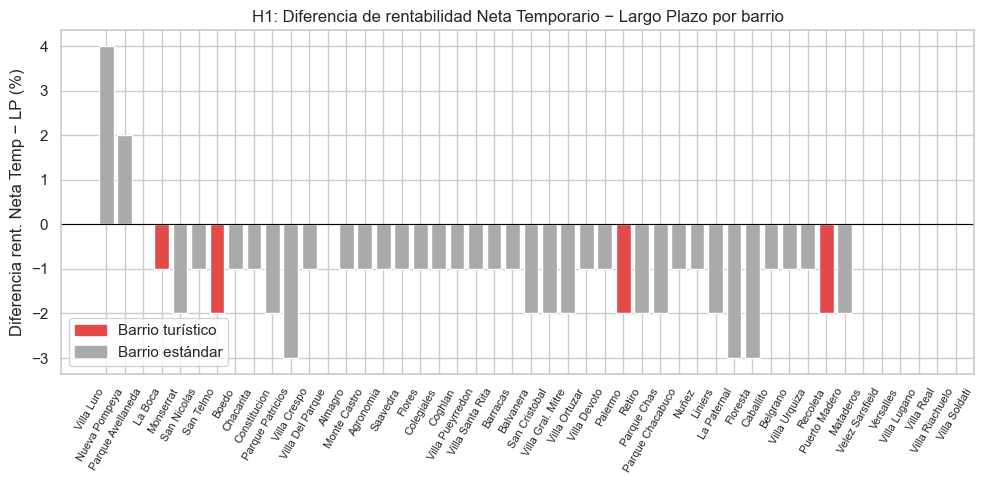

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
kpis_sorted = kpis.sort_values('rent_neta_temp_pct', ascending=False)
x = range(len(kpis_sorted))
colores = ['#E24B4A' if t else '#AAAAAA' for t in kpis_sorted['es_turistico']]
ax.bar(x, kpis_sorted['rent_neta_temp_pct'] - kpis_sorted['rent_neta_lp_pct'],
       color=colores, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(kpis_sorted.index, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Diferencia rent. Neta Temp − LP (%)')
ax.set_title('H1: Diferencia de rentabilidad Neta Temporario − Largo Plazo por barrio')
patch_t = mpatches.Patch(color='#E24B4A', label='Barrio turístico')
patch_n = mpatches.Patch(color='#AAAAAA', label='Barrio estándar')
ax.legend(handles=[patch_t, patch_n])
plt.tight_layout()
plt.show()

No rechazamos la hipótesis nula, por lo cual no hay evidencia suficiente para probar que los barrios turísticos tienen una rentabilidad neta de alquiler temporario mayor a la rentabilidad neta a largo plazo. Esto en parte puede deberse a que en pruebas como Mann Whitney con tan pocos barrios turísticos (n=4), puede ser que la muestra no sea lo suficientemente grande para detectar la diferencia.

### H2 — Mayor precio/m² ≠ Mayor rentabilidad

In [ ]:
# ── H2: Los barrios con mayor precio/m² no son los de mayor rentabilidad neta ──
# H₀: ρ(precio_m2, rent_neta_lp) ≥ 0  (relación nula o positiva)
# H₁: ρ(precio_m2, rent_neta_lp) < 0  (correlación negativa → barrios caros rinden menos)

kpis = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis.copy()

# precio_m2_mediano ya está en df_kpis, lo usamos directamente
h2 = kpis[['rent_neta_lp_pct', 'precio_m2_mediano']].dropna()

# ── TEST 1: Spearman (relación continua, todos los barrios) ──
rho, p_rho = spearmanr(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'])
# H₁ es direccional (negativa) → p-valor unilateral = p_bilateral / 2
p_unilateral = p_rho / 2 if rho < 0 else 1 - p_rho / 2

print('=== H2: Precio/m² vs Rentabilidad Neta LP ===')
print('H₀: ρ ≥ 0  |  H₁: ρ < 0  |  α = 0.05')
print(f'\nSpearman ρ = {rho:.3f}')
print(f'p-valor bilateral = {p_rho:.4f}  →  p-valor unilateral = {p_unilateral:.4f}')
if p_unilateral < 0.05 and rho < 0:
    print('→ Rechazamos H₀: correlación negativa significativa. Barrios más caros rinden menos. H2 CONFIRMADA.')
elif p_rho < 0.05 and rho > 0:
    print('→ Rechazamos H₀ en sentido contrario: correlación positiva. H2 NO confirmada.')
else:
    print('→ No rechazamos H₀: sin evidencia de correlación negativa significativa.')

# ── TEST 2: Mann-Whitney top-10 vs resto (complementario / narrativo) ──
N_TOP = 10
top_barrios  = h2.nlargest(N_TOP, 'precio_m2_mediano')
resto        = h2[~h2.index.isin(top_barrios.index)]

stat_mw, p_mw = mannwhitneyu(
    top_barrios['rent_neta_lp_pct'].dropna(),
    resto['rent_neta_lp_pct'].dropna(),
    alternative='less'   # H₁: top-10 rinden MENOS que el resto
)
print(f'\n── Mann-Whitney (top-{N_TOP} precio/m² vs resto) ──')
print(f'H₀: rent. neta top-{N_TOP} ≥ resto  |  H₁: top-{N_TOP} rinden menos')
print(f'U = {stat_mw:.2f}, p-valor = {p_mw:.4f}')
if p_mw < 0.05:
    print(f'→ Rechazamos H₀: los {N_TOP} barrios más caros tienen rentabilidad neta significativamente menor.')
else:
    print(f'→ No rechazamos H₀: no hay diferencia significativa entre top-{N_TOP} y el resto.')

=== H2: Precio/m² vs Rentabilidad Neta LP ===
H₀: ρ ≥ 0  |  H₁: ρ < 0  |  α = 0.05

Spearman ρ = -0.806
p-valor bilateral = 0.0000  →  p-valor unilateral = 0.0000
→ Rechazamos H₀: correlación negativa significativa. Barrios más caros rinden menos. H2 CONFIRMADA.

── Mann-Whitney (top-10 precio/m² vs resto) ──
H₀: rent. neta top-10 ≥ resto  |  H₁: top-10 rinden menos
U = 58.00, p-valor = 0.0002
→ Rechazamos H₀: los 10 barrios más caros tienen rentabilidad neta significativamente menor.


Para confirmar si los barrios con mayor precio por metro cuadrado tienen no tienen mayor rentabilidad neta que el resto de los barrios, decidimos hacer dos pruebas. En primera instancia, realizamos una prueba de Spearman para analizar la relación entre el precio por metro cuadrado y la rentabilidad a lo largo de todos los barrios. Rechazamos la hipótesis nula, por lo cual encontramos una correlación negativa entre estas dos variables. 

Asimismo, decidimos tomar los 10 barrios con mayor precio por metro cuadrado mediano para analizar si estos rinden menos que el resto de los 38 barrios. Rechazamos la hipótesis nula, por lo cual hay suficiente evidencia para sugerir que los 10 barrios con precio/m2 más alto tienen una rentabilidad menor. 

Esto podría sugerir que, para aquellos clientes que estén buscando obtener una rentabilidad neta alta sin preferencia particular por el barrio en el que decide realizar su inversión, probablemente no recomendemos los barrios con mayor precio/metro cuadrado. 

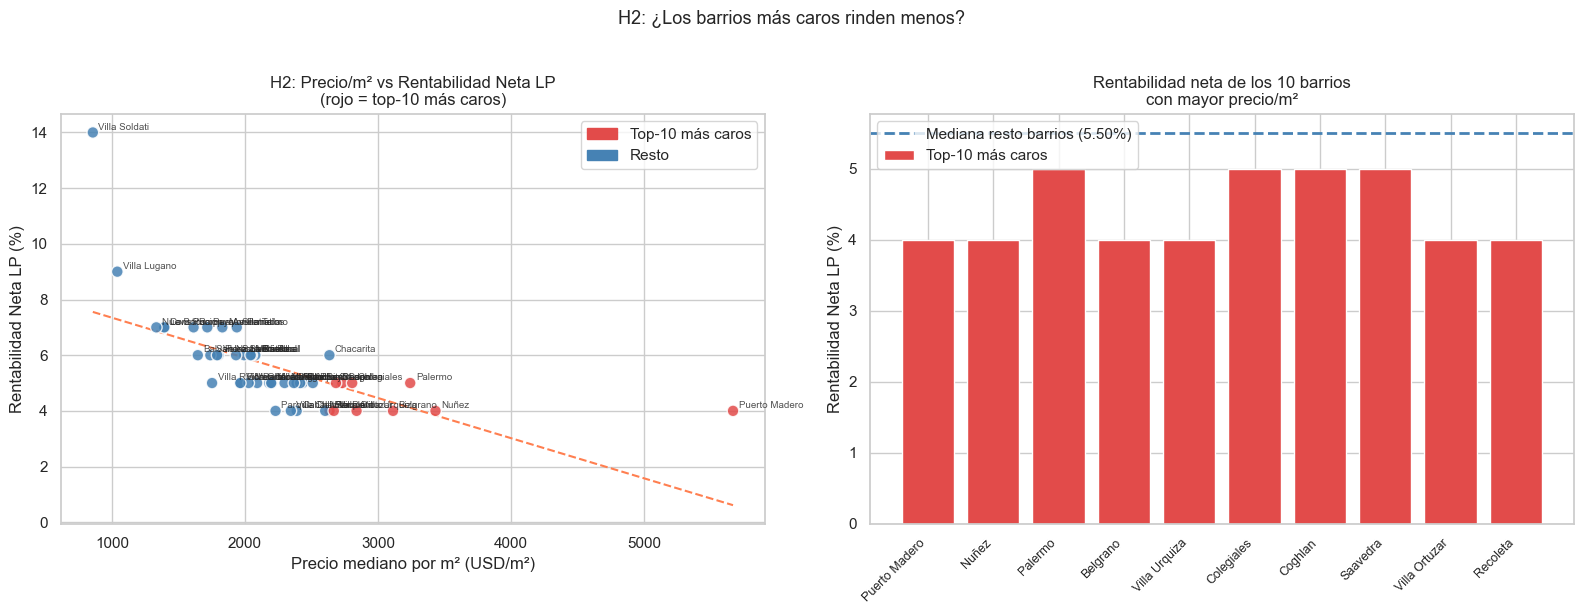

In [ ]:
# ── FIGURA 1: scatter con línea de tendencia (todos los barrios) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colores_scatter = ['#E24B4A' if b in top_barrios.index else 'steelblue' for b in h2.index]
ax.scatter(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'],
           color=colores_scatter, s=70, alpha=0.85, edgecolors='white', zorder=3)
for barrio, row in h2.iterrows():
    ax.annotate(barrio, (row['precio_m2_mediano'], row['rent_neta_lp_pct']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')
xr = np.linspace(h2['precio_m2_mediano'].min(), h2['precio_m2_mediano'].max(), 100)
ax.plot(xr, np.poly1d(np.polyfit(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'], 1))(xr),
        '--', color='coral', linewidth=1.5, label=f'Tendencia (ρ={rho:.2f})')
ax.set_xlabel('Precio mediano por m² (USD/m²)')
ax.set_ylabel('Rentabilidad Neta LP (%)')
ax.set_title('H2: Precio/m² vs Rentabilidad Neta LP\n(rojo = top-10 más caros)')
patch_top  = mpatches.Patch(color='#E24B4A', label=f'Top-{N_TOP} más caros')
patch_rest = mpatches.Patch(color='steelblue', label='Resto')
ax.legend(handles=[patch_top, patch_rest])

# ── FIGURA 2: barras top-10 vs mediana del resto ──
ax2 = axes[1]
mediana_resto = resto['rent_neta_lp_pct'].median()
top_sorted = top_barrios.sort_values('precio_m2_mediano', ascending=False)

bars = ax2.bar(range(len(top_sorted)), top_sorted['rent_neta_lp_pct'],
               color='#E24B4A', edgecolor='white', label=f'Top-{N_TOP} más caros')
ax2.axhline(mediana_resto, color='steelblue', linewidth=2, linestyle='--',
            label=f'Mediana resto barrios ({mediana_resto:.2f}%)')
ax2.set_xticks(range(len(top_sorted)))
ax2.set_xticklabels(top_sorted.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Rentabilidad Neta LP (%)')
ax2.set_title(f'Rentabilidad neta de los {N_TOP} barrios\ncon mayor precio/m²')
ax2.legend()

plt.suptitle('H2: ¿Los barrios más caros rinden menos?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

El primer gráfico resalta la tendencia negativa entre el precio por metro cuadrado y la rentabilidad neta, y el segundo muestra claramente la diferencia que los 10 barrios más caros tienen en términos de rentabildiad con el resto. 

### H3 — Amenities incrementan precio de venta pero no de alquiler

Usamos **Mann-Whitney U** para comparar el precio/m² entre propiedades con y sin amenity para cada tipo de operación.

In [21]:
df.columns

Index(['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura',
       'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda',
       'accesible_movilidad_reducida', 'acepta_caucion',
       'agua_caliente_central', 'ambientes', 'antiguedad_años',
       'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños',
       'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio',
       'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla',
       'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'expensas',
       'sobre_avenida', 'precio_por_m2', 'segmento_zona',
       'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2',
       'amenities_count', 'm2_relativo_barrio', 'precio_usd',
       'precio_por_m2_usd', 'dist_subte_km', 'lat_barrio', 'lon_barrio'],
      dtype='object')

In [ ]:
AMENITIES_H3 = ['pileta', 'gimnasio', 'balcon', 'baulera', 'parrilla', 'sum']
#TODO: revisar si queremos agregar mas columnas de amenities. estas dentro de todo me parecen bien pq son las amenities en las q uno piensa al referirse a amenities del edifico
amenities_presentes = [a for a in AMENITIES_H3 if a in df.columns]

resultados_h3 = []
for amenity in amenities_presentes:
    for operacion in ['venta', 'alquiler', 'alquiler_temporal']:
        subset = df[(df['operacion'] == operacion) & df['precio_por_m2_usd'].notna()]
        con    = subset[subset[amenity] == 1]['precio_por_m2_usd']
        sin_am = subset[subset[amenity] == 0]['precio_por_m2_usd']
        if len(con) < 10 or len(sin_am) < 10:
            continue
        stat, p = mannwhitneyu(con, sin_am, alternative='greater')
        resultados_h3.append({
            'amenity': amenity,
            'operacion': operacion,
            'mediana_con': con.median(),
            'mediana_sin': sin_am.median(),
            'dif_%': (con.median() - sin_am.median()) / sin_am.median() * 100,
            'p_valor': p,
            'significativo': 'Sí' if p < 0.05 else 'No'
        })

df_h3 = pd.DataFrame(resultados_h3)
print('=== H3: Impacto de amenities en precio/m² por tipo de operación ===')
print(df_h3.to_string(index=False))

print('\n=== Conclusión por amenity ===')
for amenity in amenities_presentes:
    fila_venta    = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'venta')]
    fila_alq      = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'alquiler')]
    fila_alq_temp = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'alquiler_temporal')]

    sig_venta    = (not fila_venta.empty)    and fila_venta['significativo'].values[0]    == 'Sí'
    sig_alq      = (not fila_alq.empty)      and fila_alq['significativo'].values[0]      == 'Sí'
    sig_alq_temp = (not fila_alq_temp.empty) and fila_alq_temp['significativo'].values[0] == 'Sí'

    # Venta vs Alquiler LP
    if fila_venta.empty or fila_alq.empty:
        concl_lp = '⬜ Sin datos suficientes'
    elif sig_venta and not sig_alq:
        concl_lp = '✅ H3 confirmada (venta sí, alquiler LP no)'
    elif sig_venta and sig_alq:
        concl_lp = '⚠️ Incrementa precio en venta y alquiler LP'
    else:
        concl_lp = '❌ H3 no confirmada (venta no significativa)'

    # Venta vs Alquiler Temporal
    if fila_venta.empty or fila_alq_temp.empty:
        concl_temp = '⬜ Sin datos suficientes'
    elif sig_venta and not sig_alq_temp:
        concl_temp = '✅ H3 confirmada (venta sí, alquiler temp no)'
    elif sig_venta and sig_alq_temp:
        concl_temp = '⚠️ Incrementa precio en venta y alquiler temporal'
    else:
        concl_temp = '❌ H3 no confirmada (venta no significativa)'

    print(f'\n{amenity}')
    print(f'  vs alquiler LP:   {concl_lp}')
    print(f'  vs alquiler temp: {concl_temp}')

=== H3: Impacto de amenities en precio/m² por tipo de operación ===
 amenity         operacion  mediana_con  mediana_sin  dif_%  p_valor significativo
  pileta             venta    3,365.116    2,342.600 43.649    0.000            Sí
  pileta          alquiler       17.163       12.367 38.776    0.000            Sí
  pileta alquiler_temporal       21.094       15.682 34.511    0.000            Sí
gimnasio             venta    3,661.972    2,416.473 51.542    0.000            Sí
gimnasio          alquiler       20.000       12.519 59.758    0.000            Sí
gimnasio alquiler_temporal       23.077       16.129 43.077    0.000            Sí
  balcon             venta    2,684.211    2,266.667 18.421    0.000            Sí
  balcon          alquiler       13.349       12.620  5.778    0.000            Sí
  balcon alquiler_temporal       17.668       16.406  7.692    0.000            Sí
 baulera             venta    2,831.592    2,500.000 13.264    0.000            Sí
 baulera          a

### H4 — Cercanía al subte impacta en el precio/m²

In [29]:
#TODO: las distancias dan cualquier cosa. es por esto de usar los centroides, no es muy accurate. encontrar otra forma de calcular las distancias

In [24]:
subset_h4 = df[
    (df['operacion'] == 'venta') &
    df['precio_por_m2_usd'].notna() &
    df['dist_subte_km'].notna()
].copy()

rho_h4, p_h4 = spearmanr(subset_h4['dist_subte_km'], subset_h4['precio_por_m2_usd'])

print('=== H4: Distancia al subte vs Precio/m² (ventas, en USD) ===')
print(f'n = {len(subset_h4):,} propiedades')
print(f'Correlación de Spearman ρ = {rho_h4:.3f}, p-valor = {p_h4:.4f}')
if p_h4 < 0.05:
    if rho_h4 < 0:
        print('→ Rechazamos H₀: mayor distancia al subte → menor precio/m². H4 CONFIRMADA.')
    else:
        print('→ Rechazamos H₀: correlación positiva (barrios periféricos pueden tener precio alto).')
else:
    print('→ No rechazamos H₀: no hay correlación significativa con la distancia al subte.')

# Agrupamos por barrio para la visualización
h4_barrio = (
    subset_h4.groupby('barrio_oficial')
    .agg(
        precio_m2_mediano=('precio_por_m2_usd', 'median'),
        dist_subte=('dist_subte_km', 'first')
    )
    .dropna()
)

=== H4: Distancia al subte vs Precio/m² (ventas, en USD) ===
n = 28,506 propiedades
Correlación de Spearman ρ = 0.492, p-valor = 0.0000
→ Rechazamos H₀: correlación positiva (barrios periféricos pueden tener precio alto).


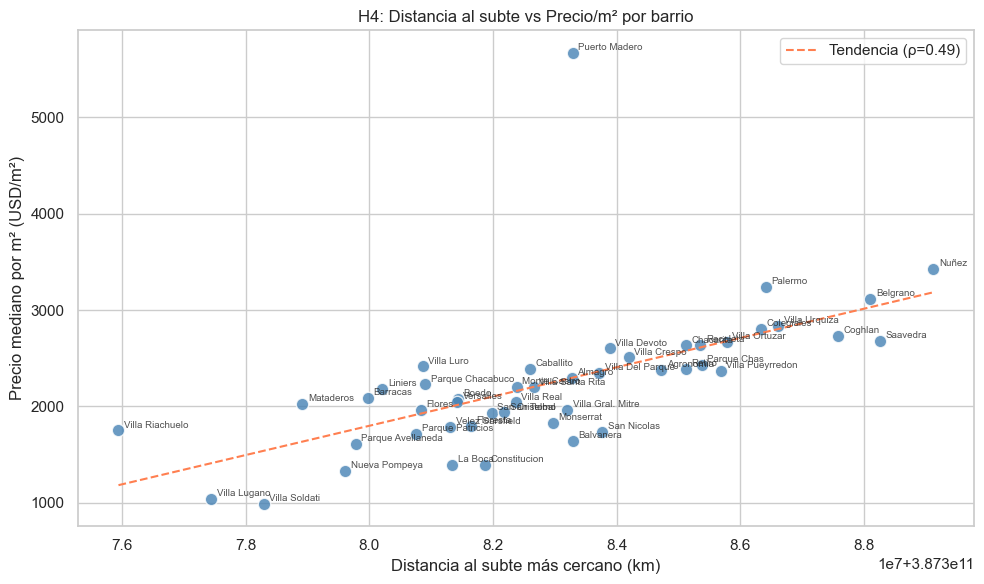

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(h4_barrio['dist_subte'], h4_barrio['precio_m2_mediano'],
           color='steelblue', s=80, alpha=0.8, edgecolors='white')
for barrio, row in h4_barrio.iterrows():
    ax.annotate(barrio, (row['dist_subte'], row['precio_m2_mediano']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')
z = np.polyfit(h4_barrio['dist_subte'], h4_barrio['precio_m2_mediano'], 1)
xr = np.linspace(h4_barrio['dist_subte'].min(), h4_barrio['dist_subte'].max(), 100)
ax.plot(xr, np.poly1d(z)(xr), '--', color='coral', linewidth=1.5,
        label=f'Tendencia (ρ={rho_h4:.2f})')
ax.set_xlabel('Distancia al subte más cercano (km)')
ax.set_ylabel('Precio mediano por m² (USD/m²)')
ax.set_title('H4: Distancia al subte vs Precio/m² por barrio')
ax.legend()
plt.tight_layout()
plt.show()

---
# 4. Reducción de Dimensionalidad y Creación de Índices Sintéticos

El proceso de feature engineering de la entrega anterior generó una gran cantidad de variables binarias de amenities. Usarlas todas en los modelos introduce **multicolinealidad** y dificulta la interpretación. 

Aplicamos dos técnicas complementarias:

- **PCA** sobre las variables continuas (precio/m², m², ambientes, antigüedad, dist_subte) para construir un **Índice de Valor**.
- **MCA** sobre las variables de amenities (binarias) para construir un **Índice de Lujo/Confort**.

### 4.1 PCA sobre variables continuas → Índice de Valor

In [36]:
df.head()

,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_oficial,moneda,accesible_movilidad_reducida,acepta_caucion,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,dependencia_servicio,dormitorios,expensas_incluidas_en_precio,gimnasio,lavadero,m2_total,ofrece_financiacion,parrilla,pileta,portero,sum,terraza,tiene_expensas,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count,m2_relativo_barrio,precio_usd,precio_por_m2_usd,dist_subte_km,lat_barrio,lon_barrio
0,58757240,zonaprop,alquiler,"750,000.000",Mansilla,"2,936.000",0,0,0,0,0,1,0,Recoleta,ars,0,0,0,2.000,36.000,0,0,1,0,1.000,0,1.000,False,0,1,60.000,0,0,0,0,0,1,1.000,"300,000.000",0,"12,500.000",estandar,estandar,13.528,4.111,9.434,5.000,NaN,530.035,8.834,"387,385,352,058.807",-34.586,-58.395
1,58818211,zonaprop,alquiler,"1,700,000.000",Cespedes,"2,300.000",0,0,0,1,0,0,0,Belgrano,ars,0,1,0,3.000,35.000,0,0,1,0,2.000,0,2.000,False,0,1,114.000,0,1,0,0,0,1,1.000,"400,000.000",0,"14,912.281",estandar,estandar,14.346,4.745,9.610,7.000,NaN,"1,201.413",10.539,"387,388,102,511.003",-34.555,-58.450
2,58564550,zonaprop,alquiler,"2,500.000",Riobamba,"1,200.000",0,0,0,1,1,1,0,Recoleta,usd,0,0,0,4.000,48.500,0,0,1,0,2.000,0,2.000,False,1,1,121.000,0,1,1,0,0,0,1.000,"1,150,000.000",0,20.661,estandar,estandar,7.824,4.804,3.076,9.000,NaN,"2,500.000",20.661,"387,385,352,058.807",-34.586,-58.395
3,58314210,zonaprop,alquiler,"1,300.000",Pereyra Lucena,"2,500.000",0,0,0,1,0,1,1,Palermo,usd,0,0,0,2.000,20.000,1,0,1,0,1.000,0,1.000,False,0,0,66.000,0,0,0,0,0,1,1.000,"384,500.000",0,19.697,estandar,estandar,7.171,4.205,3.030,7.000,NaN,"1,300.000",19.697,"387,386,409,004.544",-34.574,-58.422
4,58810878,zonaprop,alquiler,"3,800.000",Lola Mora,400.000,0,0,0,1,1,0,0,Puerto Madero,usd,0,0,0,3.000,14.000,0,0,0,0,2.000,0,2.000,False,1,0,117.000,0,0,1,0,0,0,1.000,"507,000.000",0,32.479,premium,premium,8.243,4.771,3.511,5.000,NaN,"3,800.000",32.479,"387,383,290,231.648",-34.609,-58.356


In [68]:
# Variables continuas para PCA (usamos solo ventas USD para tener unidades homogéneas)
VARS_PCA = ['precio_por_m2_usd', 'm2_total', 'antiguedad_años', 'dist_subte_km']
vars_pca_ok = [v for v in VARS_PCA if v in df.columns]

df_pca_base = df[
    (df['operacion'] == 'venta') & (df['moneda'] == 'usd')
][vars_pca_ok].dropna()

print(f'Registros válidos para PCA: {len(df_pca_base):,}')
print(f'Variables usadas: {vars_pca_ok}')

Registros válidos para PCA: 28,506
Variables usadas: ['precio_por_m2_usd', 'm2_total', 'antiguedad_años', 'dist_subte_km']


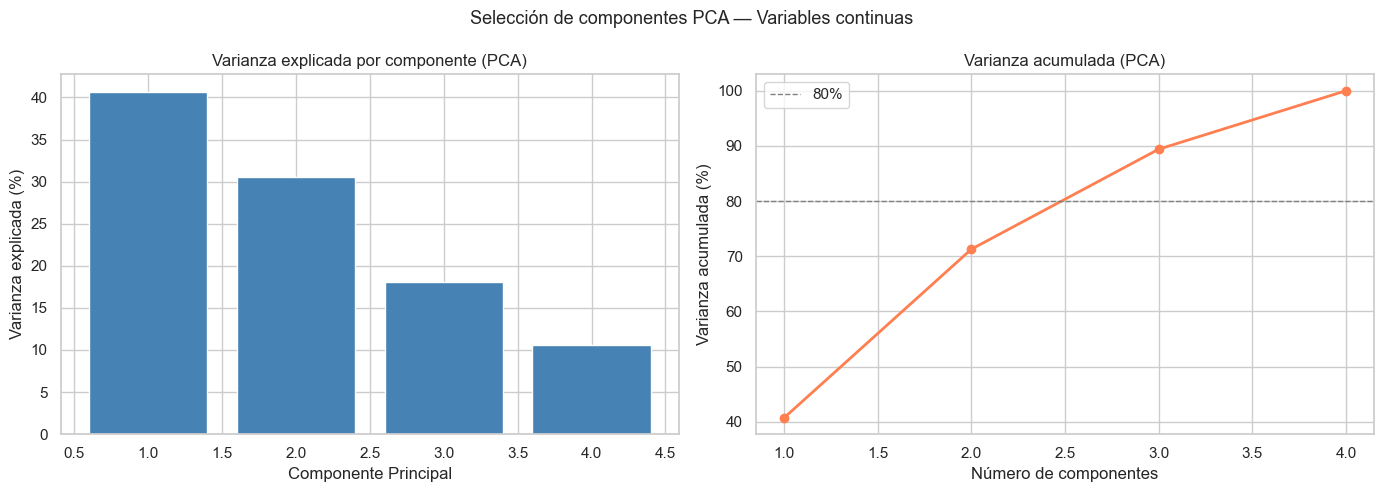

Varianza explicada por componente:
  PC1: 40.7% (acumulado: 40.7%)
  PC2: 30.6% (acumulado: 71.3%)
  PC3: 18.1% (acumulado: 89.4%)
  PC4: 10.6% (acumulado: 100.0%)


In [69]:
# Escalamos (PCA es sensible a la escala)
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df_pca_base)

# Ajustamos PCA con todos los componentes para el gráfico de codo
pca_full = PCA(n_components=len(vars_pca_ok), random_state=SEED)
pca_full.fit(X_pca)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por componente
axes[0].bar(range(1, len(vars_pca_ok)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente (PCA)')

# Varianza acumulada
axes[1].plot(range(1, len(vars_pca_ok)+1), varianza_acumulada * 100,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(80, linestyle='--', color='gray', linewidth=1, label='80%')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada (PCA)')
axes[1].legend()

plt.suptitle('Selección de componentes PCA — Variables continuas', fontsize=13)
plt.tight_layout()
plt.show()

print('Varianza explicada por componente:')
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.1f}% (acumulado: {varianza_acumulada[i]*100:.1f}%)')

=== Loadings del PCA (correlación variable → componente) ===
                     PC1   PC2
precio_por_m2_usd  0.676 0.021
m2_total           0.255 0.748
antiguedad_años   -0.404 0.655
dist_subte_km      0.561 0.106


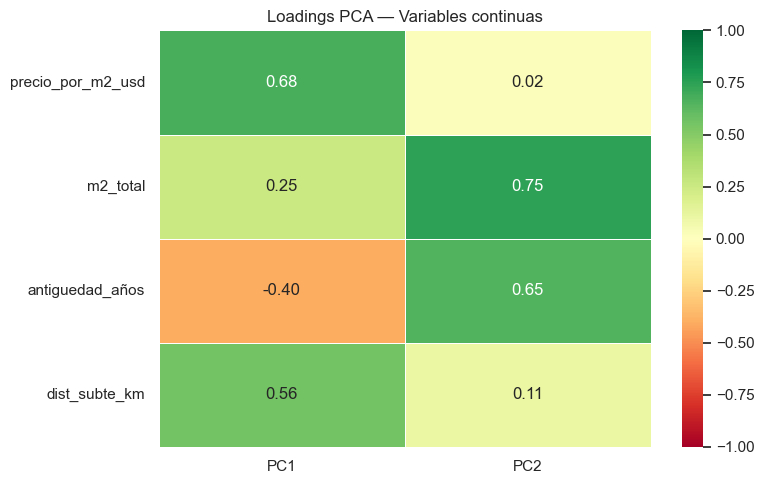

In [70]:
# Elegimos 2 componentes principales (criterio: explicar ~70-80% de la varianza)
N_PCA = 2
pca_2 = PCA(n_components=N_PCA, random_state=SEED)
coords_pca = pca_2.fit_transform(X_pca)

# Interpretamos los loadings
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=vars_pca_ok,
    columns=[f'PC{i+1}' for i in range(N_PCA)]
)
print('=== Loadings del PCA (correlación variable → componente) ===')
print(loadings.round(3))

# Heatmap de loadings
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Loadings PCA — Variables continuas')
plt.tight_layout()
plt.show()

In [72]:
# Agregamos los scores PCA al DataFrame principal
# El PC1 captura el tamaño y precio → lo llamamos "Índice de Valor"
# El PC2 captura la antigüedad y distancia → lo llamamos "Índice de Antigüedad-Accesibilidad"

idx_pca = df_pca_base.index
df.loc[idx_pca, 'pca_valor']         = coords_pca[:, 0]
df.loc[idx_pca, 'pca_antiguedad_acc'] = coords_pca[:, 1]

print(f'Scores PCA asignados a {len(idx_pca):,} registros (ventas USD)')
print('\nEstadísticas del Índice de Valor (PC1):')
print(df['pca_valor'].dropna().describe())

Scores PCA asignados a 28,506 registros (ventas USD)

Estadísticas del Índice de Valor (PC1):
count   28,506.000
mean         0.000
std          1.276
min         -3.506
25%         -0.946
50%         -0.065
75%          0.840
max          9.572
Name: pca_valor, dtype: float64


### 4.2 MCA sobre variables de amenities → Índice de Lujo

El MCA (Multiple Correspondence Analysis) es el equivalente del PCA para variables **categóricas** (binarias en nuestro caso). Nos permite resumir la presencia de múltiples amenities en una sola dimensión continua que llamaremos **Índice de Lujo**.

In [40]:
df.head()

,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_oficial,moneda,accesible_movilidad_reducida,acepta_caucion,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,dependencia_servicio,dormitorios,expensas_incluidas_en_precio,gimnasio,lavadero,m2_total,ofrece_financiacion,parrilla,pileta,portero,sum,terraza,tiene_expensas,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count,m2_relativo_barrio,precio_usd,precio_por_m2_usd,dist_subte_km,lat_barrio,lon_barrio,pca_valor,pca_antiguedad_acc
0,58757240,zonaprop,alquiler,"750,000.000",Mansilla,"2,936.000",0,0,0,0,0,1,0,Recoleta,ars,0,0,0,2.000,36.000,0,0,1,0,1.000,0,1.000,False,0,1,60.000,0,0,0,0,0,1,1.000,"300,000.000",0,"12,500.000",estandar,estandar,13.528,4.111,9.434,5.000,NaN,530.035,8.834,"387,385,352,058.807",-34.586,-58.395,NaN,NaN
1,58818211,zonaprop,alquiler,"1,700,000.000",Cespedes,"2,300.000",0,0,0,1,0,0,0,Belgrano,ars,0,1,0,3.000,35.000,0,0,1,0,2.000,0,2.000,False,0,1,114.000,0,1,0,0,0,1,1.000,"400,000.000",0,"14,912.281",estandar,estandar,14.346,4.745,9.610,7.000,NaN,"1,201.413",10.539,"387,388,102,511.003",-34.555,-58.450,NaN,NaN
2,58564550,zonaprop,alquiler,"2,500.000",Riobamba,"1,200.000",0,0,0,1,1,1,0,Recoleta,usd,0,0,0,4.000,48.500,0,0,1,0,2.000,0,2.000,False,1,1,121.000,0,1,1,0,0,0,1.000,"1,150,000.000",0,20.661,estandar,estandar,7.824,4.804,3.076,9.000,NaN,"2,500.000",20.661,"387,385,352,058.807",-34.586,-58.395,NaN,NaN
3,58314210,zonaprop,alquiler,"1,300.000",Pereyra Lucena,"2,500.000",0,0,0,1,0,1,1,Palermo,usd,0,0,0,2.000,20.000,1,0,1,0,1.000,0,1.000,False,0,0,66.000,0,0,0,0,0,1,1.000,"384,500.000",0,19.697,estandar,estandar,7.171,4.205,3.030,7.000,NaN,"1,300.000",19.697,"387,386,409,004.544",-34.574,-58.422,NaN,NaN
4,58810878,zonaprop,alquiler,"3,800.000",Lola Mora,400.000,0,0,0,1,1,0,0,Puerto Madero,usd,0,0,0,3.000,14.000,0,0,0,0,2.000,0,2.000,False,1,0,117.000,0,0,1,0,0,0,1.000,"507,000.000",0,32.479,premium,premium,8.243,4.771,3.511,5.000,NaN,"3,800.000",32.479,"387,383,290,231.648",-34.609,-58.356,NaN,NaN


In [41]:
df.columns

Index(['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura',
       'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda',
       'accesible_movilidad_reducida', 'acepta_caucion',
       'agua_caliente_central', 'ambientes', 'antiguedad_años',
       'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños',
       'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio',
       'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla',
       'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'expensas',
       'sobre_avenida', 'precio_por_m2', 'segmento_zona',
       'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2',
       'amenities_count', 'm2_relativo_barrio', 'precio_usd',
       'precio_por_m2_usd', 'dist_subte_km', 'lat_barrio', 'lon_barrio',
       'pca_valor', 'pca_antiguedad_acc'],
      dtype='object')

In [64]:
# Variables binarias de amenities disponibles
''' AMENITIES_MCA = ['losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida', 'acepta_caucion',
       'agua_caliente_central','apto_profesional', 'ascensor', 'balcon', 'baulera',  'dependencia_servicio','expensas_incluidas_en_precio',
       'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla',
       'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'sobre_avenida'] '''

AMENITIES_MCA = ['losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado','accesible_movilidad_reducida', 'acepta_caucion',
       'agua_caliente_central', 'ambientes', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños',
       'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio',
       'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla',
       'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 
       'sobre_avenida','segmento_zona',
       'segmento_zona_modelo']


amenities_mca_ok = [a for a in AMENITIES_MCA if a in df.columns]

# MCA requiere variables categóricas → convertimos a strings
df_mca_base = df[amenities_mca_ok].fillna(0).astype(str)

print(f'Variables para MCA: {amenities_mca_ok}')

Variables para MCA: ['losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida', 'acepta_caucion', 'agua_caliente_central', 'ambientes', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños', 'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'sobre_avenida', 'segmento_zona', 'segmento_zona_modelo']


In [65]:
mca = prince.MCA(
    n_components=2,
    n_iter=10,
    random_state=SEED
)
mca = mca.fit(df_mca_base)

# Varianza explicada
try:
    eig = mca.eigenvalues_summary_
    print('=== MCA: Varianza explicada por componente ===')
    print(eig)
except Exception:
    print('Eigenvalues no disponibles en esta versión de prince.')

# Coordenadas de las filas (scores individuales)
coords_mca = mca.row_coordinates(df_mca_base)

# El primer componente (Dim 0) representa el eje de "cantidad de amenities"
# → lo usamos como Índice de Lujo
df['indice_lujo'] = coords_mca.iloc[:, 0].values

print('\nEstadísticas del Índice de Lujo (MCA Dim 0):')
print(df['indice_lujo'].describe())

Eigenvalues no disponibles en esta versión de prince.

Estadísticas del Índice de Lujo (MCA Dim 0):
count   51,992.000
mean         0.000
std          0.364
min         -0.628
25%         -0.295
50%         -0.089
75%          0.209
max          1.876
Name: indice_lujo, dtype: float64


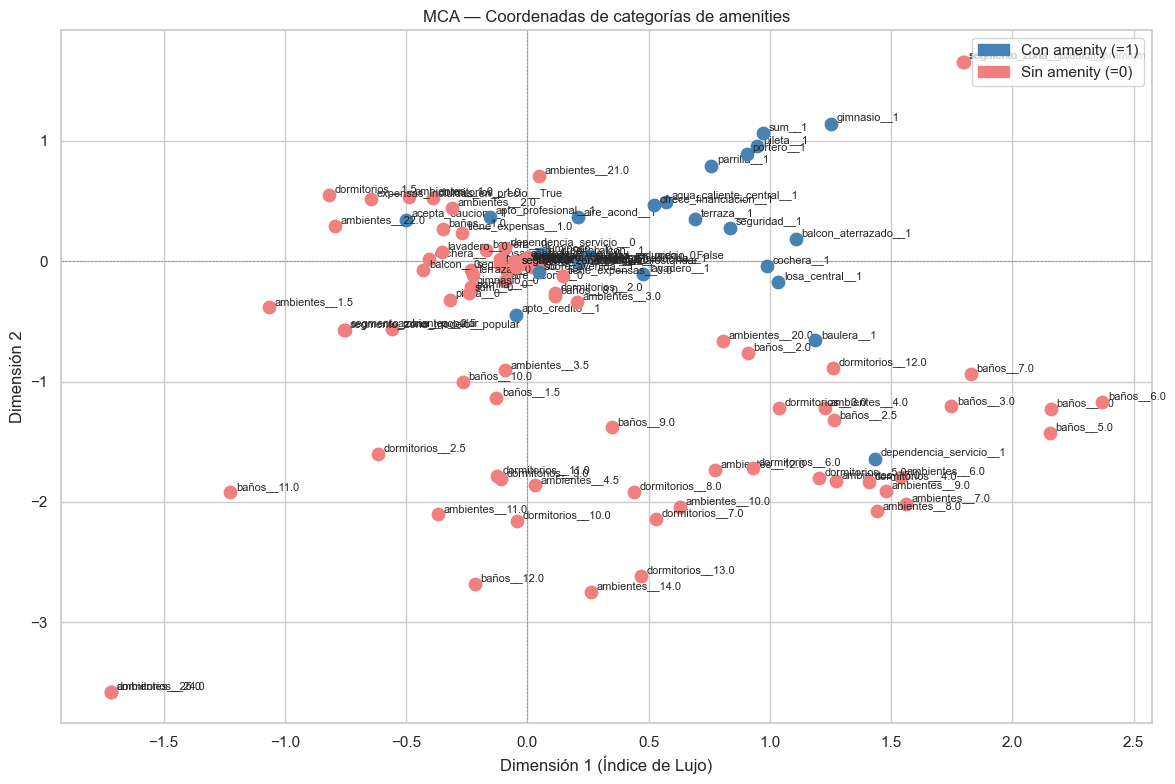

In [66]:
# Visualización: coordenadas de las categorías (column coordinates)
try:
    col_coords = mca.column_coordinates(df_mca_base)
    col_coords.columns = ['Dim0', 'Dim1']
    col_coords['variable'] = [c.rsplit('_', 1)[0] for c in col_coords.index]
    col_coords['valor'] = [c.rsplit('_', 1)[1] if '_' in c else c for c in col_coords.index]

    fig, ax = plt.subplots(figsize=(12, 8))
    for _, row in col_coords.iterrows():
        color = 'steelblue' if row['valor'] == '1' else 'lightcoral'
        ax.scatter(row['Dim0'], row['Dim1'], color=color, s=80, zorder=3)
        ax.annotate(row.name, (row['Dim0'], row['Dim1']),
                    fontsize=8, xytext=(4, 2), textcoords='offset points')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Dimensión 1 (Índice de Lujo)')
    ax.set_ylabel('Dimensión 2')
    ax.set_title('MCA — Coordenadas de categorías de amenities')
    p1 = mpatches.Patch(color='steelblue', label='Con amenity (=1)')
    p0 = mpatches.Patch(color='lightcoral', label='Sin amenity (=0)')
    ax.legend(handles=[p1, p0])
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Visualización de coordenadas no disponible: {e}')

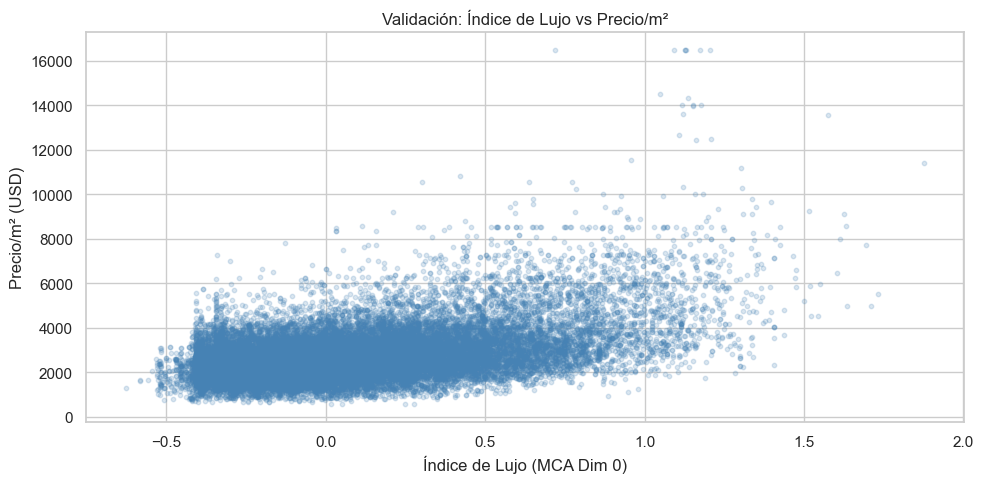

Spearman ρ (Índice de Lujo vs precio/m²) = 0.427, p=0.0000


In [67]:
# Validación del Índice de Lujo: ¿tiene sentido con el precio?
fig, ax = plt.subplots(figsize=(10, 5))
subset_lujo = df[
    (df['operacion'] == 'venta') & (df['moneda'] == 'usd') &
    df['indice_lujo'].notna() & df['precio_por_m2'].notna()
]
ax.scatter(subset_lujo['indice_lujo'], subset_lujo['precio_por_m2'],
           alpha=0.2, s=10, color='steelblue')
ax.set_xlabel('Índice de Lujo (MCA Dim 0)')
ax.set_ylabel('Precio/m² (USD)')
ax.set_title('Validación: Índice de Lujo vs Precio/m²')
plt.tight_layout()
plt.show()

rho_lujo, p_lujo = spearmanr(
    subset_lujo['indice_lujo'], subset_lujo['precio_por_m2']
)
print(f'Spearman ρ (Índice de Lujo vs precio/m²) = {rho_lujo:.3f}, p={p_lujo:.4f}')